# 03. Ridge Regression Modeling

Batch 1만으로 Ridge의 `alpha`를 선택하고 모델을 학습합니다. Batch 2·3은 모델 선택에 사용하지 않고 최종 외부 평가에만 사용합니다.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.features import FEATURE_COLUMNS, split_by_batch
from src.train import (
    calculate_regression_metrics,
    fit_final_model,
    generate_nested_cv_predictions,
    predict_dataset,
)

FEATURE_PATH = PROJECT_ROOT / 'data' / 'processed' / 'battery_features.csv'
RESULTS_DIR = PROJECT_ROOT / 'results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

if not FEATURE_PATH.is_file():
    raise FileNotFoundError(
        '피처 파일이 없습니다. 02_feature_engineering.ipynb를 먼저 실행하세요.'
    )

## 데이터 분리

Batch를 섞어 무작위 train/test 분할하지 않습니다. Batch 1은 학습·교차검증, Batch 2·3은 외부 평가에 사용합니다.

In [2]:
feature_df = pd.read_csv(FEATURE_PATH)
train_df, batch2_df, batch3_df = split_by_batch(feature_df)

split_summary = pd.DataFrame({
    'dataset': ['Batch 1 Train', 'Batch 2 Test', 'Batch 3 Test'],
    'cells': [len(train_df), len(batch2_df), len(batch3_df)],
    'life_min': [
        train_df['cycle_life'].min(),
        batch2_df['cycle_life'].min(),
        batch3_df['cycle_life'].min(),
    ],
    'life_max': [
        train_df['cycle_life'].max(),
        batch2_df['cycle_life'].max(),
        batch3_df['cycle_life'].max(),
    ],
})
display(split_summary)

,dataset,cells,life_min,life_max
0,Batch 1 Train,46,534.0,1227.0
1,Batch 2 Test,39,392.0,1186.0
2,Batch 3 Test,44,541.0,1935.0


## Batch 1 Nested Cross-Validation

Outer fold는 성능 평가, inner fold는 `alpha` 선택에 사용합니다. Imputer와 StandardScaler도 각 학습 fold에서만 fit됩니다.

In [3]:
cv_predictions = generate_nested_cv_predictions(train_df)
cv_metrics = calculate_regression_metrics(
    train_df['cycle_life'],
    cv_predictions,
)
display(pd.DataFrame([{'dataset': 'Batch 1 Nested CV', **cv_metrics}]).round(3))

,dataset,MAE,RMSE,MAPE_pct,R2
0,Batch 1 Nested CV,75.023,92.968,8.791,0.741


## 최종 모델 학습 및 외부 평가

Batch 1 전체에서 최종 `alpha`를 선택하고 학습한 뒤 Batch 2·3을 각각 한 번 평가합니다.

In [4]:
final_search = fit_final_model(train_df)
best_model = final_search.best_estimator_
best_alpha = final_search.best_params_['model__alpha']
print(f'선택된 Ridge alpha: {best_alpha:g}')

batch2_predictions = predict_dataset(final_search, batch2_df)
batch3_predictions = predict_dataset(final_search, batch3_df)

performance_df = pd.DataFrame([
    {'dataset': 'Batch 1 Nested CV', **cv_metrics},
    {
        'dataset': 'Batch 2 Test',
        **calculate_regression_metrics(
            batch2_predictions['actual'],
            batch2_predictions['predicted'],
        ),
    },
    {
        'dataset': 'Batch 3 Test',
        **calculate_regression_metrics(
            batch3_predictions['actual'],
            batch3_predictions['predicted'],
        ),
    },
])
display(performance_df.round(3))
performance_df.to_csv(RESULTS_DIR / 'model_performance.csv', index=False)

선택된 Ridge alpha: 0.0001


,dataset,MAE,RMSE,MAPE_pct,R2
0,Batch 1 Nested CV,75.023,92.968,8.791,0.741
1,Batch 2 Test,145.813,163.611,29.431,0.444
2,Batch 3 Test,156.706,258.077,12.543,0.308


## 회귀계수 해석

입력 피처는 표준화되므로 계수의 절댓값으로 상대적인 영향 크기를 비교할 수 있습니다. 부호는 다른 피처가 동일할 때 예측 수명이 변하는 방향을 뜻합니다.

In [5]:
ridge_model = best_model.named_steps['model']
coefficient_df = pd.DataFrame({
    'feature': FEATURE_COLUMNS,
    'standardized_coefficient': ridge_model.coef_,
}).sort_values('standardized_coefficient', key=abs, ascending=False)
display(coefficient_df.round(3))

,feature,standardized_coefficient
0,log_delta_q_variance,-162.892
1,mean_chargetime,-1.638


## 예측값 비교 및 오류 분석

점선에 가까울수록 실제 Cycle Life와 예측값이 일치합니다. Batch 3 장수명 셀의 과소예측 여부를 함께 확인합니다.

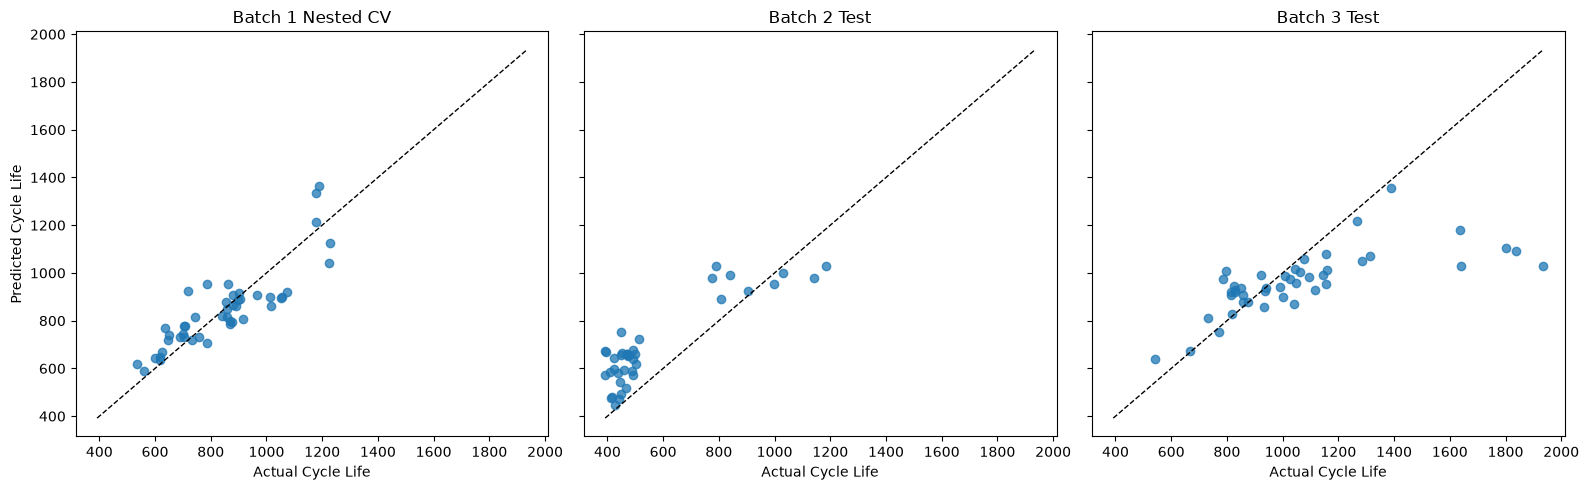

,batch,cell_key,actual,predicted,error,absolute_error
121,Batch 3,Batch 3-C38,1935.0,1028.31,-906.69,906.69
92,Batch 3,Batch 3-C07,1836.0,1090.99,-745.01,745.01
128,Batch 3,Batch 3-C45,1801.0,1104.98,-696.02,696.02
125,Batch 3,Batch 3-C42,1642.0,1028.93,-613.07,613.07
101,Batch 3,Batch 3-C16,1638.0,1180.58,-457.42,457.42
64,Batch 2,Batch 2-C18,449.0,751.80,302.80,302.80
52,Batch 2,Batch 2-C06,393.0,674.62,281.62,281.62
61,Batch 2,Batch 2-C15,396.0,668.62,272.62,272.62
102,Batch 3,Batch 3-C17,1315.0,1070.83,-244.17,244.17
55,Batch 2,Batch 2-C09,791.0,1029.35,238.35,238.35


In [6]:
cv_prediction_df = train_df[['batch', 'cell_key']].copy()
cv_prediction_df['actual'] = train_df['cycle_life'].to_numpy()
cv_prediction_df['predicted'] = cv_predictions
cv_prediction_df['error'] = (
    cv_prediction_df['predicted'] - cv_prediction_df['actual']
)
cv_prediction_df['absolute_error'] = cv_prediction_df['error'].abs()

all_predictions = pd.concat(
    [cv_prediction_df, batch2_predictions, batch3_predictions],
    ignore_index=True,
)
all_predictions.to_csv(RESULTS_DIR / 'predictions.csv', index=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True)
plot_data = [
    ('Batch 1 Nested CV', cv_prediction_df),
    ('Batch 2 Test', batch2_predictions),
    ('Batch 3 Test', batch3_predictions),
]
global_min = all_predictions[['actual', 'predicted']].min().min()
global_max = all_predictions[['actual', 'predicted']].max().max()

for axis, (title, predictions) in zip(axes, plot_data):
    axis.scatter(predictions['actual'], predictions['predicted'], alpha=0.75)
    axis.plot(
        [global_min, global_max],
        [global_min, global_max],
        color='black', linestyle='--', linewidth=1,
    )
    axis.set_title(title)
    axis.set_xlabel('Actual Cycle Life')
axes[0].set_ylabel('Predicted Cycle Life')
plt.tight_layout()
plt.show()

largest_errors = all_predictions.nlargest(10, 'absolute_error')
largest_errors.to_csv(RESULTS_DIR / 'error_analysis.csv', index=False)
display(largest_errors.round(2))